In [4]:
import os
import numpy as np
import arviz as az
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import ustreasurycurve as ustcurve

from Library.Utility import UST_TENOR_MAP
from Library.OptionPricerBSM1973 import BlackScholesMertonPut
from Library.SkewCalibrationKimYi import KimYiSkewCalibrationSystematic
from scipy.optimize import minimize
from nelson_siegel_svensson.calibrate import calibrate_nss_ols

az.style.use("arviz-darkgrid")

DATA_PATH_STR = r"/Users/josephyi/Library/Mobile Documents/com~apple~CloudDocs/Data/Implied Volatility"
UND_TICKERS_DICT = {'systematic': '^SPX', 'idiosyncratic': ['COIN']}
DIVIDEND_YIELDS = {'^SPX': 1.25}
EXPIRY_MAP = {0: 11, 1: 10, 2: 9, 3: 8, 4: 7}

In [5]:
valuation_date_array = pd.bdate_range('2025-03-18', '2025-04-17')
# https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics?data=yield%27
rates_data_df = ustcurve.nominalRates(valuation_date_array[0].strftime("%Y-%m-%d"), valuation_date_array[-1].strftime("%Y-%m-%d")).set_index('date')
rates_data_df = pd.DataFrame(index=pd.date_range(rates_data_df.index.min(), rates_data_df.index.max())).join(rates_data_df).ffill(axis=1).bfill(axis=1).ffill().bfill()
rates_tenors = np.array([UST_TENOR_MAP[x] for x in rates_data_df.columns])
rates_data_df.head()

,1m,1.5m,2m,3m,4m,6m,1y,2y,3y,5y,7y,10y,20y,30y
2025-03-18,4.37,4.35,4.33,4.34,4.29,4.29,4.13,4.04,4.01,4.07,4.18,4.29,4.61,4.58
2025-03-19,4.37,4.34,4.32,4.33,4.30,4.29,4.10,3.99,3.95,4.03,4.14,4.25,4.58,4.56
2025-03-20,4.36,4.34,4.34,4.33,4.29,4.27,4.06,3.95,3.93,4.01,4.12,4.24,4.57,4.55
2025-03-21,4.36,4.33,4.33,4.33,4.29,4.26,4.04,3.94,3.92,4.00,4.12,4.25,4.60,4.59
2025-03-22,4.36,4.33,4.33,4.33,4.29,4.26,4.04,3.94,3.92,4.00,4.12,4.25,4.60,4.59


In [169]:
PATH_STR = os.path.join(DATA_PATH_STR, UND_TICKERS_DICT['systematic'].split("^")[-1])

mkt_vol_df1 = pd.concat([pd.read_csv(os.path.join(PATH_STR, file)) for file in sorted(os.listdir(PATH_STR))])

mkt_vol_df2 = []
for underlying_name in UND_TICKERS_DICT['idiosyncratic']:

    PATH_STR = os.path.join(DATA_PATH_STR, underlying_name)

    tmp_df = pd.concat([pd.read_csv(os.path.join(PATH_STR, file)) for file in sorted(os.listdir(PATH_STR))])

    mkt_vol_df2.append(tmp_df)

mkt_vol_df2 = pd.concat(mkt_vol_df2)
mkt_vol_df = pd.concat([mkt_vol_df1, mkt_vol_df2])

mkt_vol_df.quote_date = pd.to_datetime(mkt_vol_df.quote_date)
mkt_vol_df.expiration = pd.to_datetime(mkt_vol_df.expiration)

mkt_vol_df['iEXPIRY'] = (mkt_vol_df.expiration - mkt_vol_df.quote_date).dt.days
mkt_vol_df['dEXPIRY'] = mkt_vol_df.iEXPIRY / 365

mkt_vol_df['dUND_PRICE'] = mkt_vol_df.active_underlying_price_1545
mkt_vol_df['dUND_STRIKE'] = mkt_vol_df.strike
mkt_vol_df['dMONEYNESS'] = mkt_vol_df.dUND_STRIKE / mkt_vol_df.dUND_PRICE * 100.
mkt_vol_df['dMKT_IMP_VOL'] = mkt_vol_df.implied_volatility_1545

mask = mkt_vol_df.option_type=='C'
mkt_vol_df['bIS_CALL_OPTION'] = False
mkt_vol_df.loc[mask, 'bIS_CALL_OPTION'] = True

mask  = (mkt_vol_df.trade_volume > 0) & (mkt_vol_df.iEXPIRY > 5) & (mkt_vol_df.dMKT_IMP_VOL > 0)
mkt_vol_df = mkt_vol_df.loc[mask]

mask = (mkt_vol_df.option_type=='P') & (mkt_vol_df.dMONEYNESS <= 100.) & (mkt_vol_df.dMONEYNESS >= 50.)
mkt_vol_df1 = mkt_vol_df.loc[mask]
mask = (mkt_vol_df.option_type=='C') & (mkt_vol_df.dMONEYNESS >= 100.) & (mkt_vol_df.dMONEYNESS <= 150.)
mkt_vol_df2 = mkt_vol_df.loc[mask]

mkt_vol_df = pd.concat([mkt_vol_df1, mkt_vol_df2])

for t in mkt_vol_df.quote_date.unique():
    rate_fitter, _ = calibrate_nss_ols(rates_tenors, rates_data_df.xs(t).to_numpy() / 100)
    mask = (mkt_vol_df.quote_date==t)
    mkt_vol_df.loc[mask, 'dRISK_FREE_RATE'] = mkt_vol_df.loc[mask, 'dEXPIRY'].apply(rate_fitter)

mkt_vol_df['dDIVIDEND_YIELD'] = DIVIDEND_YIELDS[mkt_vol_df.underlying_symbol.iloc[0]] / 100.

vegas = []
for tup in mkt_vol_df.itertuples():
    vega = BlackScholesMertonPut(
        und_price=np.array(tup.dUND_PRICE),
        und_strike=np.array(tup.dUND_STRIKE),
        risk_free_rate=np.array(tup.dRISK_FREE_RATE),
        dividend_yield=np.array(tup.dDIVIDEND_YIELD),
        time_to_expiry=np.array(tup.dEXPIRY)
    ).vega(np.array(tup.dMKT_IMP_VOL)) / 100.
    vegas.append(vega[0, 0])

mkt_vol_df['dVEGA'] = vegas

In [170]:
params = np.array([.2, .2, 5., 22., 7.])

method = 'SLSQP'

bounds = {
    'dSIGMA': (1e-4, None),
    'dPPROB': (0., 1.),
    'dLAMB': (1e-4, None),
    'dETA1': (1.5, None),
    'dETA2': (0.5, None)
}

In [144]:
systematic_name = UND_TICKERS_DICT['systematic']
underlying_names = UND_TICKERS_DICT['idiosyncratic']
for underlying_name in underlying_names:

    for valuation_date in valuation_date_array:

        if valuation_date in mkt_vol_df.loc[mkt_vol_df.underlying_symbol==underlying_name, 'quote_date'].unique():

            valuation_date_str = valuation_date.strftime("%Y%m%d")

            key = f'{valuation_date.strftime("%Y%m%d")}-{underlying_name}'

            display('--------')
            display(key)
            display('--------')

            filename = f"vol_surf_params_calibrated_{underlying_name.split('^')[-1]}_{valuation_date_str}.csv"

            T = EXPIRY_MAP[valuation_date.weekday()]

            if (valuation_date >= pd.to_datetime('20250407')) and (valuation_date < pd.to_datetime('20250414')):
                T = T - 1

            mask = (mkt_vol_df.underlying_symbol==underlying_name) & (mkt_vol_df.quote_date==valuation_date) & (mkt_vol_df.iEXPIRY==T) & (mkt_vol_df.dMONEYNESS >= 50.) & (mkt_vol_df.dMONEYNESS <= 150.)

            tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')

['COIN']

In [188]:
underlying_name = UND_TICKERS_DICT['systematic']

calib_results = {}
for valuation_date in valuation_date_array:

    if valuation_date in mkt_vol_df.quote_date.unique():

        valuation_date_str = valuation_date.strftime("%Y%m%d")

        key = f'{underlying_name}-{valuation_date_str}'

        display('--------')
        display(key)
        display('--------')

        results_ = {}

        # filename = f"vol_surf_params_calibrated_{underlying_name.split('^')[-1]}_{valuation_date_str}.csv"

        T = EXPIRY_MAP[valuation_date.weekday()]

        if (valuation_date >= pd.to_datetime('20250407')) and (valuation_date < pd.to_datetime('20250414')):
            T = T - 1

        mask  = (mkt_vol_df.underlying_symbol==underlying_name)
        mask &= (mkt_vol_df.quote_date==valuation_date)
        mask &= (mkt_vol_df.iEXPIRY==T)
        mask &= (mkt_vol_df.dMONEYNESS >= 50.)
        mask &= (mkt_vol_df.dMONEYNESS <= 150.)

        tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')

        # tmp_df = tmp_df.loc[tmp_df.root==underlying_name.split("^")[-1]]

        vol_fitter = KimYiSkewCalibrationSystematic(
            mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy(),
            und_price=tmp_df.dUND_PRICE.to_numpy(),
            und_strike=tmp_df.dUND_STRIKE.to_numpy(),
            risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
            dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
            time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
            is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
            option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
        )

        minimizer_results = minimize(
            vol_fitter.target,
            x0=params,
            method=method,
            bounds=bounds.values(),
            tol=1e-6,
            options={'maxiter': 1e4},
            # constraints=({'type': 'ineq', 'fun': psi_constraint_aggregate})
        )

        display(minimizer_results)

        results_[valuation_date_str] = minimizer_results

        calib_results[key] = minimizer_results

'--------'

'^SPX-20250318'

'--------'

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0005310816928841525
       x: [ 1.623e-01  8.392e-01  4.902e+00  2.200e+01  7.094e+00]
     nit: 10
     jac: [-7.058e-04 -2.174e-06  1.096e-04 -4.098e-05 -3.356e-05]
    nfev: 61
    njev: 10

'--------'

...

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0003811427326668462
       x: [ 2.483e-01  6.033e-01  4.935e+00  2.200e+01  7.074e+00]
     nit: 9
     jac: [ 3.992e-05  1.475e-05  7.123e-05 -2.199e-05 -5.866e-05]
    nfev: 54
    njev: 9

'--------'

'^SPX-20250417'

'--------'

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0006333152069998239
       x: [ 2.109e-01  8.003e-01  4.905e+00  2.200e+01  7.100e+00]
     nit: 10
     jac: [-4.310e-04  6.121e-06  1.024e-04 -3.843e-05 -4.493e-05]
    nfev: 60
    njev: 10

In [136]:
calib_results['20250403-SPX']

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0003999386202246918
       x: [ 2.162e-01  6.196e-01  4.929e+00  2.200e+01  7.073e+00]
     nit: 10
     jac: [-2.286e-05  5.463e-05  8.688e-05 -2.767e-05 -5.260e-05]
    nfev: 60
    njev: 10

In [138]:
valuation_date = '20250404'
T = EXPIRY_MAP[pd.to_datetime(valuation_date).weekday()]
mask = (mkt_vol_df.quote_date==valuation_date) & (mkt_vol_df.iEXPIRY==T) & (mkt_vol_df.dMONEYNESS >= 50.) & (mkt_vol_df.dMONEYNESS <= 150.)
tmp_df = mkt_vol_df.loc[mask].sort_values('dMONEYNESS')
tmp_df.dMKT_IMP_VOL *= 100.
expiry_date = tmp_df.expiration.iloc[0]
tmp_df

,underlying_symbol,quote_date,root,expiration,strike,option_type,open,high,low,close,...,iEXPIRY,dEXPIRY,dUND_PRICE,dUND_STRIKE,dMONEYNESS,dMKT_IMP_VOL,bIS_CALL_OPTION,dRISK_FREE_RATE,dDIVIDEND_YIELD,dVEGA
10815,^SPX,2025-04-04,SPXW,2025-04-11,2600.0,P,0.45,0.45,0.06,0.20,...,7,0.019178,5139.89,2600.0,50.584740,153.16,False,0.044343,0.0125,0.011394
10817,^SPX,2025-04-04,SPXW,2025-04-11,2800.0,P,0.45,0.98,0.10,0.20,...,7,0.019178,5139.89,2800.0,54.475874,139.25,False,0.044343,0.0125,0.014467
10819,^SPX,2025-04-04,SPXW,2025-04-11,3000.0,P,0.70,1.50,0.20,0.85,...,7,0.019178,5139.89,3000.0,58.367008,132.51,False,0.044343,0.0125,0.028886
10821,^SPX,2025-04-04,SPXW,2025-04-11,3200.0,P,0.95,2.40,0.45,1.00,...,7,0.019178,5139.89,3200.0,62.258142,122.92,False,0.044343,0.0125,0.045854
10823,^SPX,2025-04-04,SPXW,2025-04-11,3400.0,P,1.30,3.50,0.90,1.60,...,7,0.019178,5139.89,3400.0,66.149276,114.70,False,0.044343,0.0125,0.077226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11324,^SPX,2025-04-04,SPXW,2025-04-11,6350.0,C,0.13,0.25,0.13,0.25,...,7,0.019178,5139.89,6350.0,123.543500,52.23,True,0.044343,0.0125,0.045088
11334,^SPX,2025-04-04,SPXW,2025-04-11,6475.0,C,0.18,0.18,0.18,0.18,...,7,0.019178,5139.89,6475.0,125.975459,55.92,True,0.044343,0.0125,0.038220
11336,^SPX,2025-04-04,SPXW,2025-04-11,6500.0,C,0.18,0.18,0.18,0.18,...,7,0.019178,5139.89,6500.0,126.461850,56.76,True,0.044343,0.0125,0.037726
11342,^SPX,2025-04-04,SPXW,2025-04-11,6650.0,C,0.05,0.05,0.05,0.05,...,7,0.019178,5139.89,6650.0,129.380201,53.42,True,0.044343,0.0125,0.007737


In [142]:
vol_fitter = KimYiSkewCalibrationSystematic(
    mkt_imp_vol=tmp_df.dMKT_IMP_VOL.to_numpy() / 100.,
    und_price=tmp_df.dUND_PRICE.to_numpy(),
    und_strike=tmp_df.dUND_STRIKE.to_numpy(),
    risk_free_rate=tmp_df.dRISK_FREE_RATE.to_numpy(),
    dividend_yield=tmp_df.dDIVIDEND_YIELD.to_numpy(),
    time_to_expiry=tmp_df.dEXPIRY.to_numpy(),
    is_call_option=tmp_df.bIS_CALL_OPTION.to_numpy(),
    option_weights=tmp_df.dVEGA.to_numpy() / tmp_df.dVEGA.sum()
)

tmp_df['dMOD_IMP_VOL'] = vol_fitter.model_vol(x=calib_results[f"{valuation_date}-{UND_TICKERS_DICT['systematic']}"].x) * 100.

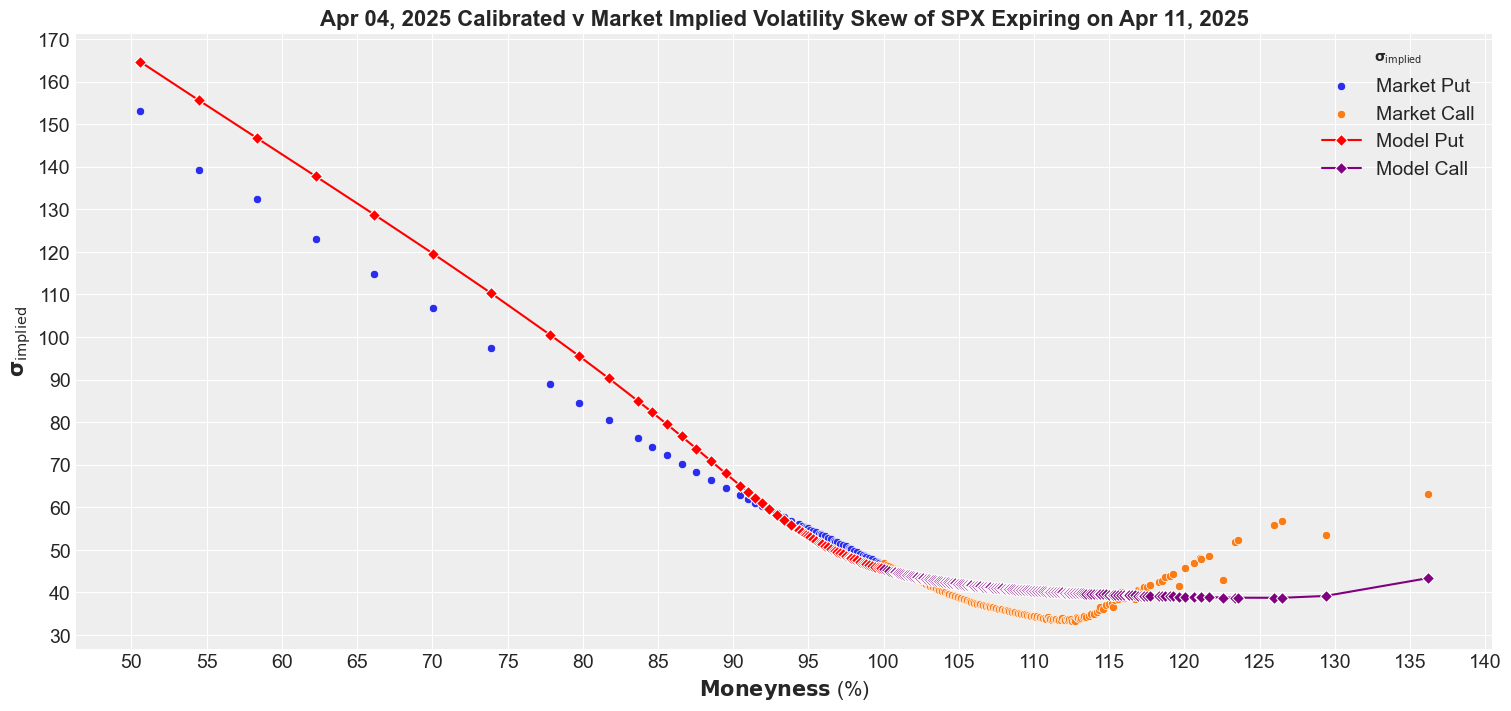

In [143]:
fig, ax = plt.subplots(figsize=(15, 7))

sns.scatterplot(data=tmp_df.loc[~tmp_df.bIS_CALL_OPTION], x='dMONEYNESS', y='dMKT_IMP_VOL', label='Market Put',  ax=ax)
sns.scatterplot(data=tmp_df.loc[tmp_df.bIS_CALL_OPTION],  x='dMONEYNESS', y='dMKT_IMP_VOL', label='Market Call', ax=ax)
sns.lineplot(data=tmp_df.loc[~tmp_df.bIS_CALL_OPTION], x='dMONEYNESS', y='dMOD_IMP_VOL', label='Model Put',  ax=ax, color='r', marker='D')
sns.lineplot(data=tmp_df.loc[tmp_df.bIS_CALL_OPTION],  x='dMONEYNESS', y='dMOD_IMP_VOL', label='Model Call', ax=ax, color='purple', marker='D')

ax.set(xlabel=rf'$\bf Moneyness$ (%)', ylabel=r'$\bf \sigma_{\text{implied}}$')
ax.legend(title=r'$\bf \sigma_{\text{implied}}$')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
ax.set_title(
    f'{pd.to_datetime(valuation_date, format="%Y%m%d").strftime("%b %d, %Y")} Calibrated v Market Implied Volatility Skew of {UND_TICKERS_DICT["systematic"].split("^")[-1]} ' +
    f'Expiring on {pd.to_datetime(expiry_date, format="%Y%m%d").strftime("%b %d, %Y")}', weight='bold'
)
# plt.savefig(f"SPX_VOL_SKEW_{valuation_date_str}.pdf", dpi=300)
plt.show();